In [ ]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print("✓", filename)

Saving train_unlabeled.p to train_unlabeled.p
Saving train_labeled.p to train_labeled.p
Saving validation.p to validation.p
Saving test.p to test.p

Uploaded files:
✓ train_unlabeled.p
✓ train_labeled.p
✓ validation.p
✓ test.p


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import TensorDataset, DataLoader

In [ ]:
import pickle

with open("train_labeled.p", "rb") as f:
    train_labeled = pickle.load(f)

with open("train_unlabeled.p", "rb") as f:
    train_unlabeled = pickle.load(f)

with open("validation.p", "rb") as f:
    validation = pickle.load(f)

with open("test.p", "rb") as f:
    test = pickle.load(f)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
import sys

# Create a dummy module and class to handle the ModuleNotFoundError
class sub:
    class subMNIST: # This class is mentioned in the pickle traceback as csub\nsubMNIST\np1
        pass
sys.modules['sub'] = sub

with open("/content/train_labeled.p", "rb") as f:
    train_labeled = pickle.load(f)

with open("/content/train_unlabeled.p", "rb") as f:
    train_unlabeled = pickle.load(f)

with open("/content/validation.p", "rb") as f:
    validation = pickle.load(f)

with open("/content/test.p", "rb") as f:
    test = pickle.load(f)

print("All files loaded successfully!")

All files loaded successfully!


In [ ]:
print("train_labeled type:", type(train_labeled))
print("train_unlabeled type:", type(train_unlabeled))
print("validation type:", type(validation))
print("test type:", type(test))

train_labeled type: <class '__main__.sub.subMNIST'>
train_unlabeled type: <class '__main__.sub.subMNIST'>
validation type: <class '__main__.sub.subMNIST'>
test type: <class 'torchvision.datasets.mnist.MNIST'>


In [ ]:
print(type(train_labeled))
print(train_labeled)

<class '__main__.sub.subMNIST'>


In [ ]:
print(vars(train_labeled))

{'train_labels': tensor([0, 0, 0,  ..., 9, 9, 9]), 'k': 3000, 'transform': Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
), 'train': True, 'root': './data', 'target_transform': None, 'train_data': tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,

In [ ]:
print("Training images shape :", train_labeled.train_data.shape)
print("Training labels shape:", train_labeled.train_labels.shape)

Training images shape : torch.Size([3000, 28, 28])
Training labels shape: torch.Size([3000])


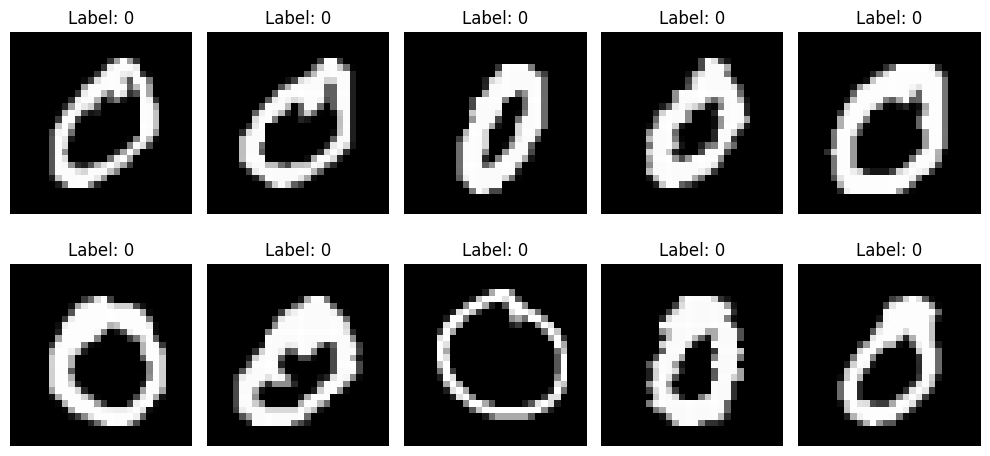

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = train_labeled.train_data[i]

    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {train_labeled.train_labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
labels = train_labeled.train_labels.numpy()

unique, counts = np.unique(labels, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

Digit 0: 300 images
Digit 1: 300 images
Digit 2: 300 images
Digit 3: 300 images
Digit 4: 300 images
Digit 5: 300 images
Digit 6: 300 images
Digit 7: 300 images
Digit 8: 300 images
Digit 9: 300 images


In [ ]:
X_train = train_labeled.train_data.float() / 255.0
y_train = train_labeled.train_labels.long()

# Add channel dimension for CNN
X_train = X_train.unsqueeze(1)

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

Training images shape: torch.Size([3000, 1, 28, 28])
Training labels shape: torch.Size([3000])


In [ ]:
print(vars(validation))

{'test_labels': tensor([0, 0, 0,  ..., 9, 9, 9]), 'k': 10000, 'transform': Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
), 'test_data': tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0

In [ ]:
X_val = validation.test_data.float() / 255.0
y_val = validation.test_labels.long()

# Add channel dimension for CNN
X_val = X_val.unsqueeze(1)

print("Validation images shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

Validation images shape: torch.Size([10000, 1, 28, 28])
Validation labels shape: torch.Size([10000])


In [ ]:
print(type(test))
print(vars(test))

<class 'torchvision.datasets.mnist.MNIST'>
{'test_labels': tensor([-1, -1, -1,  ..., -1, -1, -1]), 'transform': Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
), 'test_data': tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
      

In [72]:
X_test = test.__dict__['test_data'].clone().float() / 255.0

X_test = X_test.unsqueeze(1)

print("Test images shape:", X_test.shape)
print("Test labels:", test.__dict__['test_labels'].unique())

Test images shape: torch.Size([10000, 1, 28, 28])
Test labels: tensor([-1])


In [71]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test)

print("Training dataset :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset      :", len(test_dataset))

Training dataset : 3000
Validation dataset: 10000
Test dataset      : 10000


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [ ]:
class DigitCNN(nn.Module):

    def __init__(self):
        super(DigitCNN, self).__init__()

        self.features = nn.Sequential(

            # Convolution Layer 1
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolution Layer 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),

            nn.Dropout(0.5),

            # 10 output classes: digits 0-9
            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
model = DigitCNN().to(device)

print(model)

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully.")

Training function created successfully.


In [ ]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {train_accuracy*100:.2f}%"
    )

print("\nTraining completed successfully.")

Epoch [1/10] | Loss: 1.5575 | Accuracy: 48.40%
Epoch [2/10] | Loss: 0.6421 | Accuracy: 79.23%
Epoch [3/10] | Loss: 0.4411 | Accuracy: 86.17%
Epoch [4/10] | Loss: 0.3448 | Accuracy: 89.43%
Epoch [5/10] | Loss: 0.2776 | Accuracy: 91.43%
Epoch [6/10] | Loss: 0.2290 | Accuracy: 93.40%
Epoch [7/10] | Loss: 0.1961 | Accuracy: 94.13%
Epoch [8/10] | Loss: 0.1744 | Accuracy: 95.00%
Epoch [9/10] | Loss: 0.1407 | Accuracy: 95.63%
Epoch [10/10] | Loss: 0.1509 | Accuracy: 95.57%

Training completed successfully.


In [ ]:
def evaluate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy


val_loss, val_accuracy = evaluate_model(
    model,
    val_loader,
    criterion,
    device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Validation Loss: 0.1327
Validation Accuracy: 95.96%


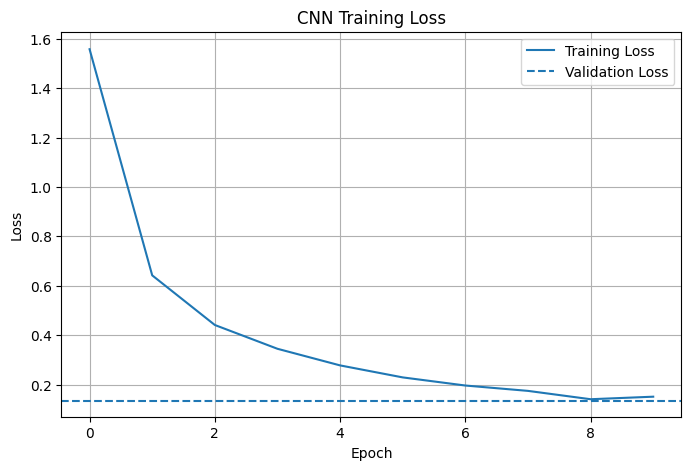

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.axhline(val_loss, linestyle="--", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

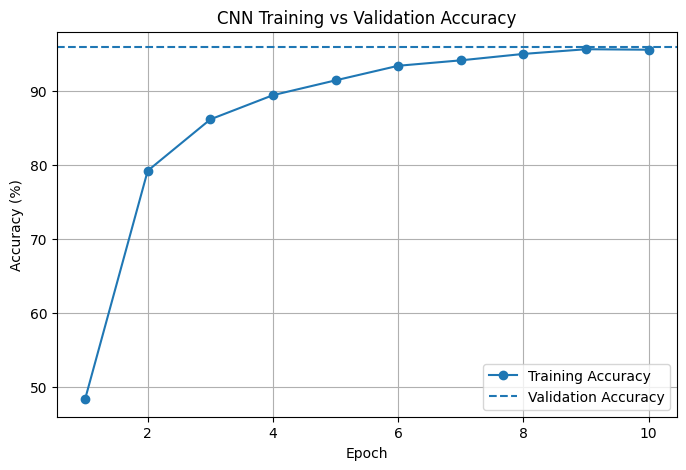

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    [acc * 100 for acc in train_accuracies],
    marker="o",
    label="Training Accuracy"
)

plt.axhline(
    val_accuracy * 100,
    linestyle="--",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions:", all_predictions.shape)
print("Actual Labels:", all_labels.shape)
print("Prediction collection completed successfully.")

Predictions: (10000,)
Actual Labels: (10000,)
Prediction collection completed successfully.


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        digits=4
    )
)

Classification Report:

              precision    recall  f1-score   support

           0     0.9850    0.9870    0.9860      1000
           1     0.9907    0.9630    0.9767      1000
           2     0.9150    0.9690    0.9412      1000
           3     0.9413    0.9460    0.9436      1000
           4     0.9876    0.9530    0.9700      1000
           5     0.9645    0.9780    0.9712      1000
           6     0.9642    0.9700    0.9671      1000
           7     0.9698    0.9620    0.9659      1000
           8     0.9513    0.9190    0.9349      1000
           9     0.9313    0.9490    0.9401      1000

    accuracy                         0.9596     10000
   macro avg     0.9601    0.9596    0.9597     10000
weighted avg     0.9601    0.9596    0.9597     10000



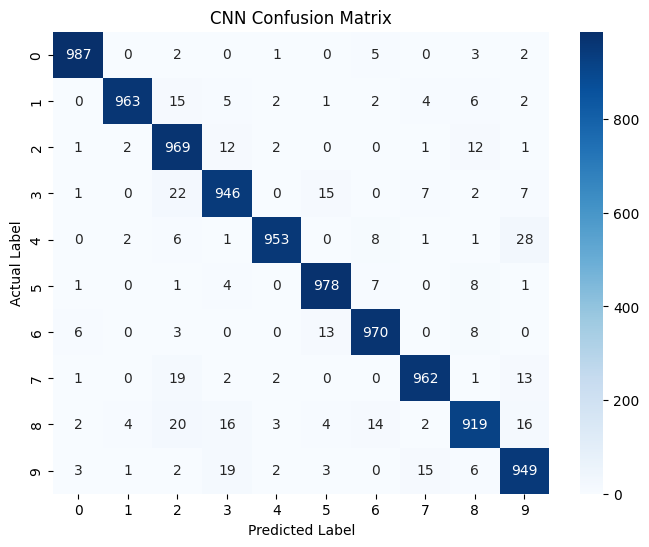

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("CNN Confusion Matrix")

plt.show()

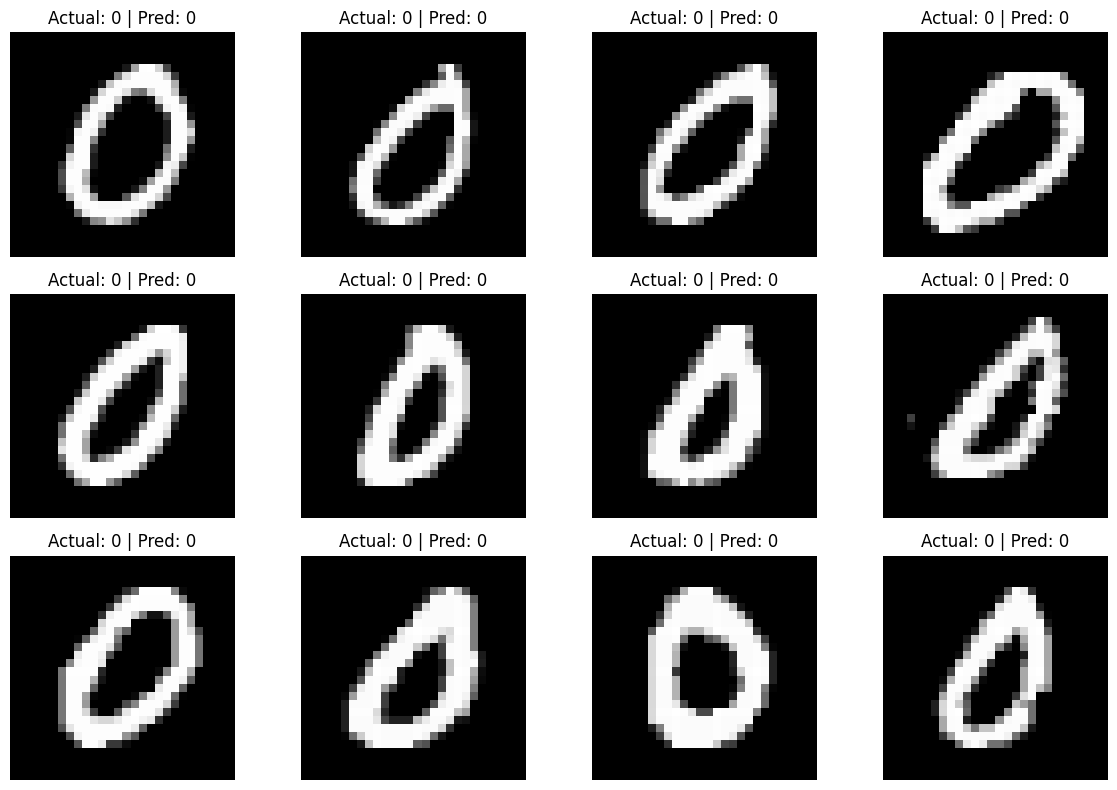

In [ ]:
model.eval()

images, labels = next(iter(val_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predictions = torch.max(outputs, 1)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    actual = labels[i].item()
    predicted = predictions[i].item()

    plt.title(f"Actual: {actual} | Pred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Total misclassified images: 404


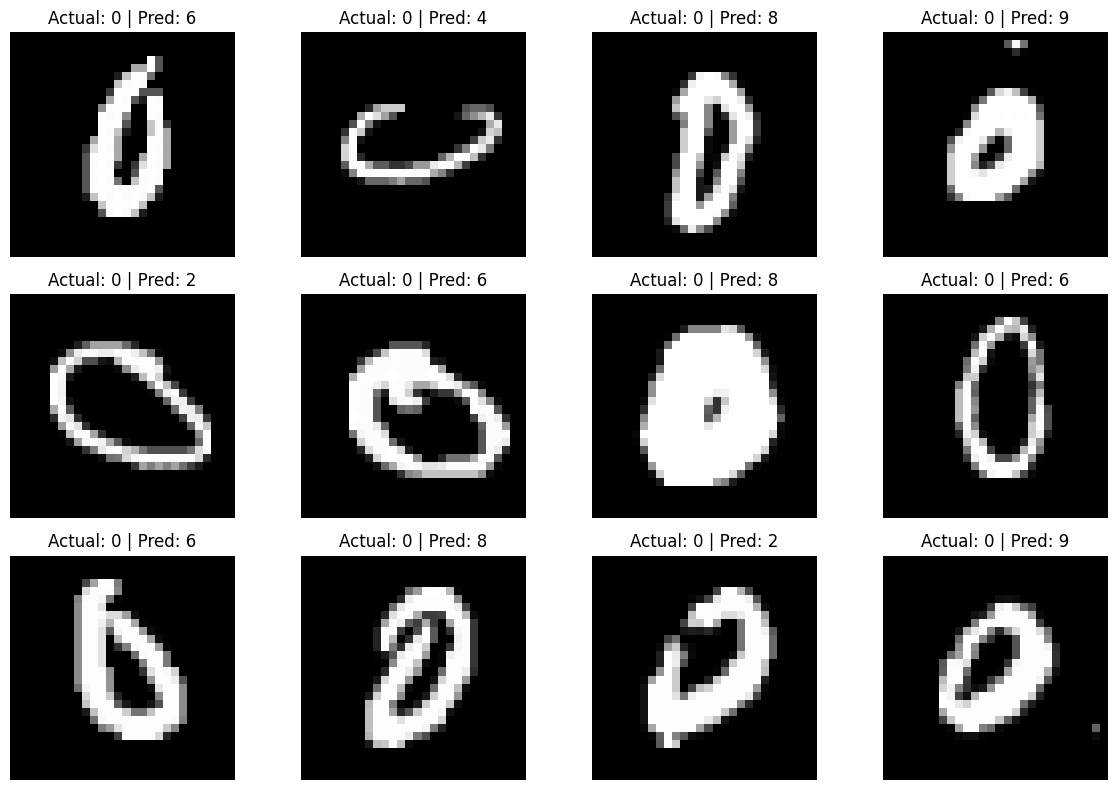

In [ ]:
model.eval()

misclassified_images = []
misclassified_actual = []
misclassified_predicted = []

with torch.no_grad():

    for images, labels in val_loader:

        images_device = images.to(device)

        outputs = model(images_device)
        _, predictions = torch.max(outputs, 1)

        wrong = predictions.cpu() != labels

        misclassified_images.extend(images[wrong])
        misclassified_actual.extend(labels[wrong].numpy())
        misclassified_predicted.extend(predictions[wrong].numpy())


print("Total misclassified images:", len(misclassified_images))

plt.figure(figsize=(12, 8))

num_images = min(12, len(misclassified_images))

for i in range(num_images):

    plt.subplot(3, 4, i + 1)

    plt.imshow(misclassified_images[i].squeeze(), cmap="gray")

    plt.title(
        f"Actual: {misclassified_actual[i]} | "
        f"Pred: {misclassified_predicted[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.eval()

test_predictions = []

with torch.no_grad():

    for (images,) in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_predictions.extend(predicted.cpu().numpy())

test_predictions = np.array(test_predictions)

print("Test predictions shape:", test_predictions.shape)
print("Unique predicted digits:", np.unique(test_predictions))
print("Test prediction completed successfully.")

Test predictions shape: (10000,)
Unique predicted digits: [0 1 2 3 4 5 6 7 8 9]
Test prediction completed successfully.


In [ ]:
model_path = "handwritten_digit_cnn.pth"

torch.save(model.state_dict(), model_path)

print(f"Model saved successfully: {model_path}")

Model saved successfully: handwritten_digit_cnn.pth


In [ ]:
from google.colab import files

files.download("handwritten_digit_cnn.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving digit_5.jpg to digit_5 (1).jpg


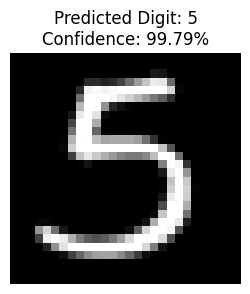

Predicted Digit: 5
Confidence: 99.79%


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load uploaded image
image = Image.open("digit_5.jpg").convert("L")

# Resize to MNIST format
image = image.resize((28, 28))

# Convert image to tensor
image_array = np.array(image)
image_tensor = torch.tensor(image_array, dtype=torch.float32) / 255.0

# Invert if the digit is dark on a white background
if image_tensor.mean() > 0.5:
    image_tensor = 1.0 - image_tensor

# Add batch and channel dimensions
image_tensor = image_tensor.unsqueeze(0).unsqueeze(0).to(device)

# Make prediction
model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.softmax(output, dim=1)

    predicted_digit = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, predicted_digit].item()

# Display result
plt.figure(figsize=(3, 3))
plt.imshow(image_tensor.cpu().squeeze(), cmap="gray")
plt.title(
    f"Predicted Digit: {predicted_digit}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.axis("off")
plt.show()

print("Predicted Digit:", predicted_digit)
print(f"Confidence: {confidence * 100:.2f}%")